# S&P 500 Options: Equal-Weight Baseline Backtests

Every model fitted in `06_linear` through `09b_patchtst` produced a set of predicted
decision-date returns. This notebook turns each of those prediction sets into a traded
strategy and measures what it earned, so that the families can be compared on money
rather than on rank correlation.

The strategy is the same for all of them, which is what makes the comparison fair. On each
weekly decision date it ranks the predicted return, keeps the highest-scoring symbols,
restricts them to the liquid option universe, and sells one at-the-money straddle - a call
and a put at the same strike and expiration - on each, equally weighted. Each straddle is
held to expiration and settled in cash at intrinsic value, with the underlying delta measured
at every session close and hedged when it breaches its threshold. Only the number of symbols
held varies across requests.

The run publishes a named, immutable population of backtest results. `13_portfolio_management`
and `15_costs` resolve that population by name and build on it, and `16_strategy_analysis` is
where the results are ranked and interpreted.

**Learning objectives**

- Turn a registered prediction set into an exact set of option contracts to trade, and check
  that the interval traded is the interval the prediction was scored over.
- Read a concentration grid out of the case study's configuration rather than choosing one.
- Publish a set of backtests as a named population whose membership is fixed before the first
  backtest runs, so that a later comparison cannot quietly gain or lose a member.

**Book reference**: Chapter 16

**Prerequisites**: the complete official prediction populations published by `06_linear`,
`07_gbm`, `08_tabular_dl` and the three sequence notebooks.

In [1]:
"""Execute the complete S&P 500 options equal-weight baseline population."""

import plotly.express as px
import polars as pl

from case_studies.research import supersedes_for_run
from case_studies.sp500_options.research_workflow import (
    official_prediction_catalog,
    open_study,
    option_decision_dates,
    option_trade_calendar,
    run_official_backtest_requests,
    strategy_request_frame,
)
from case_studies.utils.backtest_loaders import load_backtest_prices_for
from case_studies.utils.sweep_config import get_top_k_values_for, get_universe_filters_for
from utils.style import COLORS, show_plotly_with_alt

CASE_STUDY = "sp500_options"
PRIMARY_LABEL = "ret_to_expiry"
BASELINE_POPULATION = "sp500-options-baseline-validation-v1"
MODEL_POPULATIONS = (
    "sp500-options-linear-validation-v1",
    "sp500-options-gbm-validation-v1",
    "sp500-options-tabular-dl-validation-v1",
    "sp500-options-sequence-validation-v1",
)

In [2]:
EXECUTION_TIER = "canonical"
WORKSPACE: str = ""
PREVIEW_PREDICTION_HASHES: list[str] = []

# The baseline population is immutable under its name, so a run whose members have moved has to
# say which generation it retires. Anything upstream that changes a backtest identity moves them:
# here it was the corrected settlement in `02_labels`, which moved every training identity and so
# every prediction the requests below resolve. Empty for a first snapshot.
SUPERSEDES_BASELINE_POPULATION: str = "25421ed29ba5"

## Which predictions are traded

A population is a named list of prediction sets, written into the registry by the notebook
that fitted them and immutable afterwards. Resolving the four populations by name - rather
than querying the registry for whatever it happens to hold - is what makes this run
reproducible: a prediction set that arrived later cannot join the comparison, and one that
was expected and is missing raises instead of shrinking the population silently.

A preview run has no populations to resolve, because preview results never enter one. It
names its prediction sets explicitly instead.

In [3]:
study = open_study(execution_tier=EXECUTION_TIER, workspace=WORKSPACE or None)
if EXECUTION_TIER == "canonical":
    predictions = official_prediction_catalog(study, MODEL_POPULATIONS)
else:
    if not WORKSPACE or not PREVIEW_PREDICTION_HASHES:
        raise ValueError("preview execution requires WORKSPACE and PREVIEW_PREDICTION_HASHES")
    predictions = study.predictions.table(include_preview=True).filter(
        (pl.col("execution_tier") == "preview")
        & pl.col("prediction_hash").is_in(PREVIEW_PREDICTION_HASHES)
    )
    if predictions.height != len(PREVIEW_PREDICTION_HASHES):
        raise ValueError("preview prediction selection is missing or ambiguous")
if predictions.filter(~pl.col("complete")).height:
    raise RuntimeError("baseline requests contain incomplete predictions")

Each model family contributes one prediction set per configuration and per saved checkpoint,
so the table below counts what the four populations hold rather than listing them.

In [4]:
population_summary = (
    predictions.group_by("family")
    .agg(
        configurations=pl.col("config_name").n_unique(),
        checkpoints_per_configuration=(pl.len() / pl.col("config_name").n_unique()).round(1),
        prediction_sets=pl.len(),
    )
    .sort("family")
)
population_summary

family,configurations,checkpoints_per_configuration,prediction_sets
str,u32,f64,u32
"""deep_learning""",3,20.0,60
"""gbm""",15,10.0,150
"""linear""",28,1.0,28
"""tabular_dl""",3,8.0,24


## The interval the strategy trades

A backtest is only meaningful if the interval it trades is the interval the prediction was
scored over. Here the two are tied together by construction, and the table below states the
convention each date follows:

- **Decision date** - the last session of the week present in the prediction set, whose close
  is the last piece of information the model is allowed to use. That is a Friday whenever the
  set reaches one, and the session before it otherwise. The prediction is scored on this date.
- **Entry date** - the next session's close, where the straddle is actually sold. Nothing
  trades at the price that produced the signal.

The fill is a close rather than the next open because this chain has no open. The AlgoSeek
option data is one end-of-session quote per contract per day - `LastBidPrice`, `LastAskPrice`,
`LastMidPrice` - and carries no open, high or low, so a next-open fill is not a convention this
case study declined to adopt but a price that does not exist in its data. Worth stating plainly,
because a one-session delay to the next close is also the more conservative choice and reads
like one: a reader who assumes it was chosen for conservatism would also assume it could be
relaxed, and here it cannot be. `execution_delay: next_session_close` in `config/setup.yaml`
records the same fact for the engine, which resolves it to the `next_bar` execution mode.
- **Expiration** - where the position is closed, in cash, at the intrinsic value of the two
  legs. Cash settlement is not a trade, so a contract that reaches expiration pays no exit-side
  option spread. A contract whose quote history ends before its expiration date does not reach
  it: the engine buys that position back at the last quoted ask and charges the exit spread and
  commission, because that is the same trade at the same price a round-trip exit would pay.

The net delta of the straddle is measured at every session close in between, and the underlying
hedge is traded only when that delta breaches its threshold, so the price series the backtest
marks against is the daily underlying close over exactly the entry-to-expiration window.

The schedule comes from the predictions being traded, because that is where the engine reads it
from: `weekly_friday` is the last session present in each week of a prediction set, so a set that
does not reach a Friday enters on that week's Thursday. The contract artifact carries every
session, and the sessions no prediction set reaches are ones nothing enters on.

The universe filter below is applied first, for the same reason. It is a semi-join against the
price rows, so a decision date it empties is a date the engine does not rank on, and that too
can move a week's last session earlier.

In [5]:
prices = load_backtest_prices_for(CASE_STUDY, PRIMARY_LABEL, split="validation")
universe_filters = get_universe_filters_for(CASE_STUDY)
if universe_filters != ["liquid"]:
    raise ValueError(f"the canonical option universe must be liquid alone, got {universe_filters}")
decision_dates = option_decision_dates(
    study,
    predictions.get_column("prediction_hash"),
    prices=prices,
    signal={"universe_filter": universe_filters[0]},
)
trade_calendar = option_trade_calendar(decision_dates)
sessions = prices.get_column("timestamp").cast(pl.Date).unique().sort().to_frame("session")
# A straddle entered near the end of the window expires after the last priced session, so the
# holding period is measured over the candidates that open and expire inside it.
holding = (
    trade_calendar.join(
        sessions.with_row_index("entry_session").rename({"session": "entry_date"}),
        on="entry_date",
        how="inner",
    )
    .join(
        sessions.with_row_index("exit_session").rename({"session": "expiration"}),
        on="expiration",
        how="inner",
    )
    .with_columns((pl.col("exit_session") - pl.col("entry_session") + 1).alias("sessions_held"))
)
if holding.is_empty():
    raise RuntimeError("no candidate straddle resolves to sessions in the validation calendar")
if holding.filter(pl.col("sessions_held") < 2).height:
    raise RuntimeError("a candidate straddle expires on the session it is entered")

Read the figure for the spread rather than the centre: a strategy whose holding period is
fixed by an expiration calendar rather than by a chosen horizon will trade some intervals
considerably longer than others, and the cost of a day of gamma exposure is paid over each of
them.

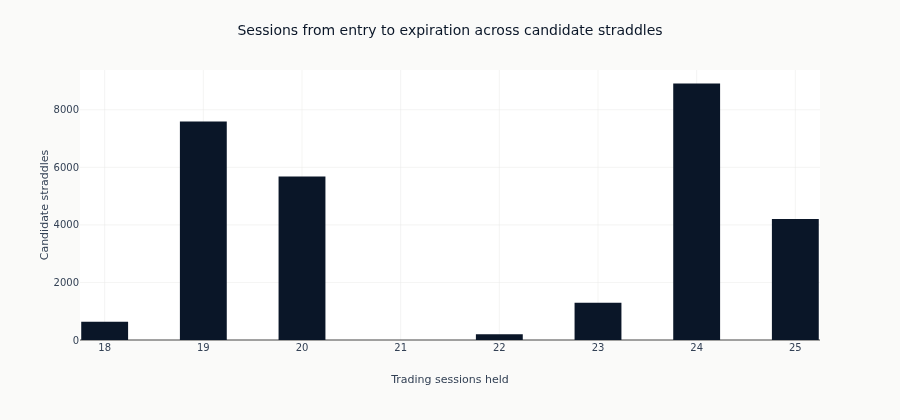

In [6]:
holding_figure = px.histogram(
    holding.select("sessions_held"),
    x="sessions_held",
    nbins=int(holding.get_column("sessions_held").max()),
    color_discrete_sequence=[COLORS["blue"]],
)
holding_figure.update_layout(
    title="Sessions from entry to expiration across candidate straddles",
    height=420,
    width=900,
    bargap=0.05,
    margin=dict(t=70),
)
holding_figure.update_xaxes(title_text="Trading sessions held")
holding_figure.update_yaxes(title_text="Candidate straddles")
show_plotly_with_alt(
    holding_figure,
    "Histogram of the number of trading sessions each candidate straddle is held from entry "
    "to expiration, over the validation period.",
)

## How many symbols to hold

`top_k` is the number of symbols the strategy is short a straddle on at any one decision
date. It is the only field that varies across the requests below, and it trades diversification
against liquidity: a small `top_k` concentrates the portfolio in the names the model scores
highest, a large one dilutes the signal across names it ranks less confidently. The grid comes
from `config/setup.yaml`, so the notebook demonstrates the sweep rather than choosing it.

The universe filter is a separate restriction and is not swept here. `setup.yaml` pins the
canonical strategy to the liquid subset - the fifth of the option surface with the tightest
quoted half-spread on each decision date - because the round-trip cost on the full surface
consumes the premium the strategy collects. `15_costs` is where the full surface is priced
against the liquid one.

In [7]:
n_symbols = prices.get_column("symbol").n_unique()
top_k_values = get_top_k_values_for(CASE_STUDY, PRIMARY_LABEL, n_symbols)
if not top_k_values:
    raise ValueError(
        f"backtest.sweep.top_k_grid[{PRIMARY_LABEL!r}] declares no value below the "
        f"{n_symbols} symbols quoted in the validation universe"
    )
print(f"Universe: {n_symbols} symbols quoted, restricted to the liquid subset each date")
print(f"Concentration grid: {top_k_values} symbols held per decision date")

Universe: 542 symbols quoted, restricted to the liquid subset each date
Concentration grid: [5, 10, 20] symbols held per decision date


## The requests

One request per prediction set and concentration. Each carries the signal in full - the
ranking method, how many symbols to keep, the universe restriction - so the request, and not
an ambient default, is what determines the strategy that runs. Holding to expiration is
enforced downstream: a request that declares an earlier exit is rejected rather than executed.

In [8]:
request_rows = []
for row in predictions.iter_rows(named=True):
    for top_k in top_k_values:
        request_rows.append(
            {
                "request_name": f"{row['prediction_hash']}-top{top_k}-liquid",
                "prediction_hash": row["prediction_hash"],
                "label": row["label"],
                "top_k": top_k,
                "signal": {
                    "method": "equal_weight_top_k",
                    "top_k": top_k,
                    "direction": "long_only",
                    "long_short": False,
                    "universe_filter": "liquid",
                },
                "allocation": None,
                "risk": None,
                "costs": None,
                "chapter": "ch16",
            }
        )
requests = strategy_request_frame(request_rows)
print(f"{requests.height} requests: {predictions.height} prediction sets x {len(top_k_values)} k")

786 requests: 262 prediction sets x 3 k


## Execute

Every request resolves its predictions to exact option contracts and publishes that resolution
as a decision artifact before any accounting happens, so what was traded is recorded
independently of what it earned. The engine then values the paired legs daily at their
midpoint, settles them at intrinsic value, carries the hedge position between sessions, and
charges the entry-side option spread plus the underlying hedge spread on each session the hedge
actually trades.

In a canonical run the population's membership is computed and written before the first
backtest executes. An interrupted run therefore resumes into the same population instead of
publishing a shorter one.

In [9]:
execution = run_official_backtest_requests(
    study,
    requests,
    population_name=BASELINE_POPULATION if EXECUTION_TIER == "canonical" else None,
    supersedes=supersedes_for_run(
        study,
        population_name=BASELINE_POPULATION,
        declared=SUPERSEDES_BASELINE_POPULATION or None,
        execution_tier=EXECUTION_TIER,
    ),
)
catalog = execution.catalog_rows.sort("request_name")
if catalog.height != requests.height or catalog.filter(~pl.col("complete")).height:
    raise RuntimeError("baseline execution did not publish every declared request")

  SKIP backtest (complete (hash=ba1b0a8e15ea)) — reusing cached result
  SKIP backtest (complete (hash=0d9538ab7d1e)) — reusing cached result


  SKIP backtest (complete (hash=232dd011d3d8)) — reusing cached result
  SKIP backtest (complete (hash=42e1c81eac8f)) — reusing cached result


  SKIP backtest (complete (hash=9650ad8d3d9d)) — reusing cached result
  SKIP backtest (complete (hash=aa6d23574ddb)) — reusing cached result


  SKIP backtest (complete (hash=6fedbb383af8)) — reusing cached result
  SKIP backtest (complete (hash=2aac696b5f7f)) — reusing cached result


  SKIP backtest (complete (hash=f30568b13ecd)) — reusing cached result
  SKIP backtest (complete (hash=911a30936402)) — reusing cached result


...

  SKIP backtest (complete (hash=59520287cab6)) — reusing cached result
  SKIP backtest (complete (hash=c3862b25a121)) — reusing cached result


  SKIP backtest (complete (hash=81026723fed3)) — reusing cached result
  SKIP backtest (complete (hash=393d886d2c3b)) — reusing cached result


  SKIP backtest (complete (hash=505ff0b94f7c)) — reusing cached result
  SKIP backtest (complete (hash=0994aa6fecdd)) — reusing cached result


  SKIP backtest (complete (hash=49c8dc789a6c)) — reusing cached result
  SKIP backtest (complete (hash=1e8e8864dabf)) — reusing cached result


  SKIP backtest (complete (hash=9aeafe4eeced)) — reusing cached result
  SKIP backtest (complete (hash=1d31daf7a67c)) — reusing cached result


## What the run produced

The Sharpe ratios below are the raw outcome of the sweep. They are not ranked here and no
configuration is preferred: choosing one needs the uncertainty around each estimate and the
count of configurations searched, which `16_strategy_analysis` computes.

In [10]:
published = (
    study.backtests.table(include_preview=EXECUTION_TIER == "preview")
    .filter(pl.col("backtest_hash").is_in(catalog.get_column("backtest_hash").to_list()))
    .select("family", "config_name", "sharpe", "backtest_hash")
    .join(catalog.select("request_name", "backtest_hash"), on="backtest_hash", how="inner")
    .join(requests.select("request_name", "top_k"), on="request_name", how="inner")
    .drop("request_name")
)
if published.height != catalog.height or published.get_column("sharpe").null_count():
    raise RuntimeError("the published baseline population is missing rows or Sharpe metrics")

In [11]:
baseline_spread = (
    published.group_by("family", "top_k")
    .agg(
        backtests=pl.len(),
        sharpe_median=pl.col("sharpe").median(),
        sharpe_min=pl.col("sharpe").min(),
        sharpe_max=pl.col("sharpe").max(),
    )
    .sort("family", "top_k")
)
baseline_spread

family,top_k,backtests,sharpe_median,sharpe_min,sharpe_max
str,i64,u32,f64,f64,f64
"""deep_learning""",5,60,-1.043818,-1.384854,-0.523876
"""deep_learning""",10,60,-1.010796,-1.164556,-0.808193
"""deep_learning""",20,60,-1.032902,-1.221832,-0.885735
"""gbm""",5,150,-0.975865,-1.442079,-0.515398
"""gbm""",10,150,-1.081738,-1.314199,-0.777047
…,…,…,…,…,…
"""linear""",10,28,-1.405889,-1.486847,-0.922553
"""linear""",20,28,-1.342038,-1.398811,-1.12612
"""tabular_dl""",5,24,-0.871816,-1.248092,-0.641709


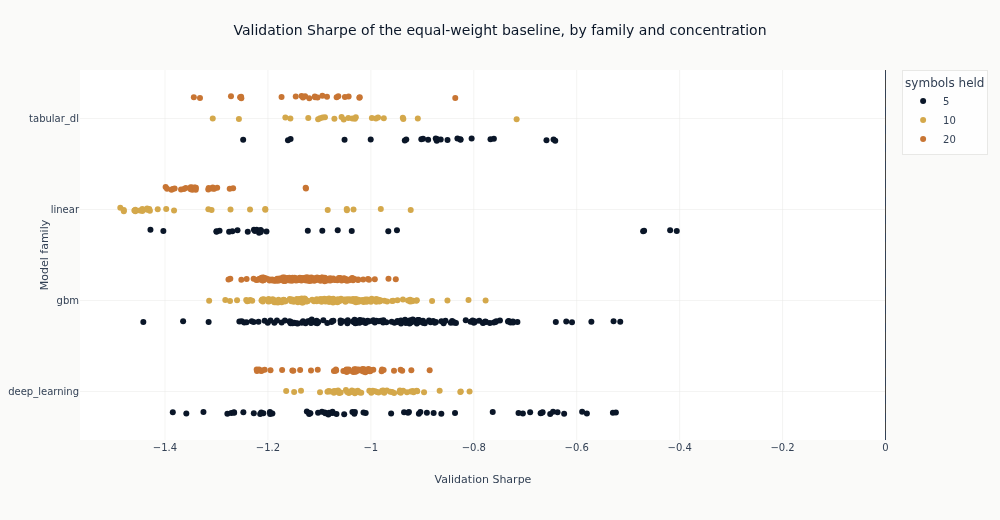

In [12]:
sharpe_figure = px.strip(
    published.with_columns(concentration=pl.col("top_k").cast(pl.String)).sort("family", "top_k"),
    x="sharpe",
    y="family",
    color="concentration",
    hover_data=["config_name", "backtest_hash"],
    color_discrete_sequence=[COLORS["blue"], COLORS["amber"], COLORS["copper"]],
)
sharpe_figure.add_vline(x=0, line_width=1, line_dash="dash", line_color=COLORS["neutral"])
sharpe_figure.update_layout(
    title="Validation Sharpe of the equal-weight baseline, by family and concentration",
    height=520,
    width=1000,
    margin=dict(t=70),
    legend_title_text="symbols held",
)
sharpe_figure.update_xaxes(title_text="Validation Sharpe")
sharpe_figure.update_yaxes(title_text="Model family")
show_plotly_with_alt(
    sharpe_figure,
    "Strip plot of validation Sharpe for every equal-weight baseline backtest, one row per "
    "model family, coloured by the number of symbols held per decision date.",
)

## Key takeaways

- A prediction set becomes a strategy only once it is resolved to specific contracts on
  specific dates; that resolution is published as its own artifact so the trades are on record
  separately from their returns.
- Fixing the population before execution is what lets a later notebook say it compared
  everything: membership cannot grow with a stray re-run or shrink with a failed one.
- The concentration grid is the only degree of freedom exercised here. Allocation weights,
  cost assumptions and risk overlays are each varied in their own notebook, so that a
  difference between two results can be attributed to one field.

**Known limitations**: every result is a validation-period estimate with no interval attached,
so nothing here supports a statement about which family or concentration is better. The
liquid-universe restriction is a modelling assumption inherited from the configuration, and
its cost is quantified in `15_costs` rather than tested here.